In [46]:
import pandas as pd
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [47]:
print(df.shape)

print(df.describe())

print(df.describe(include='object'))

(7043, 21)
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


C:\Users\WIN 10\AppData\Local\Temp\ipykernel_8476\2731505658.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     7590-VHVEG   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7043           7043         7043             7043   
unique               3              3            3                3   
top        Fiber optic             No           No               No   
freq              3096           3498         3088             3095   

       TechSupport StreamingTV StreamingMovies        Contract  \
count         7043        7043            7043            7043   
unique           3           3               3               3   
top             No          No              No  Month-to-month   
freq

In [48]:

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [49]:
df = df.dropna()

print(df.isnull().sum())

print(df.shape)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 21)


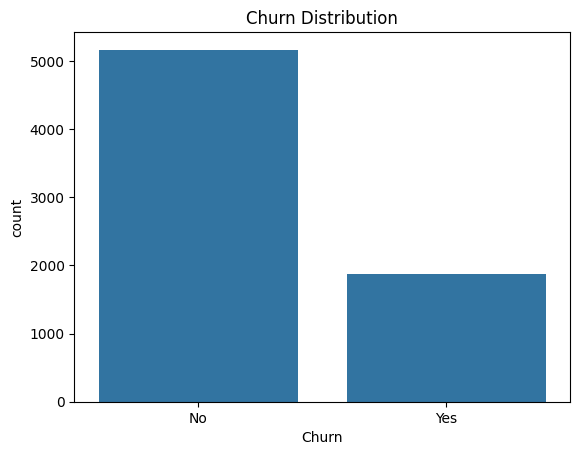

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

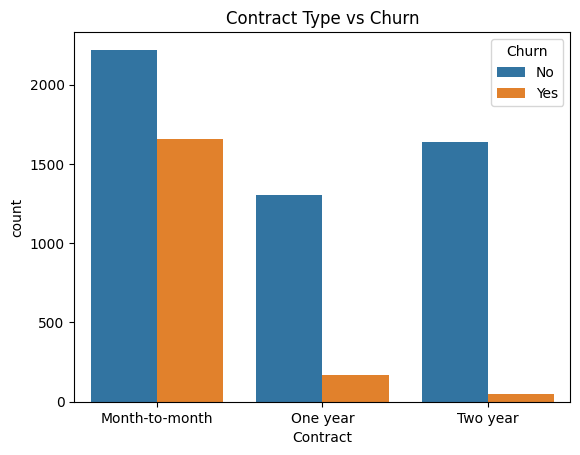

In [51]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

In [57]:

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})
df = df.drop(columns=['customerID'], errors='ignore')
df = pd.get_dummies(df, drop_first=True,dtype=int)
print(df.shape)
print(df.dtypes)

(7032, 31)
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSuppo

In [58]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Logistic Regression model trained")

Logistic Regression model trained


c:\Users\WIN 10\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
predictions = model.predict(X_test)
print(predictions[:10])
print(y_test[:10].values)

[0 0 1 0 0 0 0 1 0 0]
[0 0 1 0 0 0 0 0 0 0]


In [60]:
from sklearn.metrics import (
    accuracy_score,
    f1_score
)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.7867803837953091
F1 Score: 0.5562130177514792


In [61]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(
    random_state=42
)
tree_model.fit(X_train, y_train)
print("Decision Tree trained")

Decision Tree trained


In [62]:
tree_predictions = tree_model.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)
print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree F1 Score:", tree_f1)

Decision Tree Accuracy: 0.7249466950959488
Decision Tree F1 Score: 0.5019305019305019


In [63]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)
forest_model.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


In [64]:
forest_predictions = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_f1 = f1_score(y_test, forest_predictions)
print("Random Forest Accuracy:", forest_accuracy)
print("Random Forest F1 Score:", forest_f1)

Random Forest Accuracy: 0.7867803837953091
Random Forest F1 Score: 0.5440729483282675


In [65]:
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': forest_model.feature_importances_
})
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
print(importance_df)

                                  Feature  Importance
3                            TotalCharges    0.195188
1                                  tenure    0.174878
2                          MonthlyCharges    0.168182
10            InternetService_Fiber optic    0.045089
28         PaymentMethod_Electronic check    0.031007
13                     OnlineSecurity_Yes    0.028423
4                             gender_Male    0.027177
25                      Contract_Two year    0.025433
26                   PaperlessBilling_Yes    0.024695
5                             Partner_Yes    0.024645
19                        TechSupport_Yes    0.024510
24                      Contract_One year    0.023849
15                       OnlineBackup_Yes    0.021462
0                           SeniorCitizen    0.020709
9                       MultipleLines_Yes    0.020190
6                          Dependents_Yes    0.018880
17                   DeviceProtection_Yes    0.018629
23                    Stream

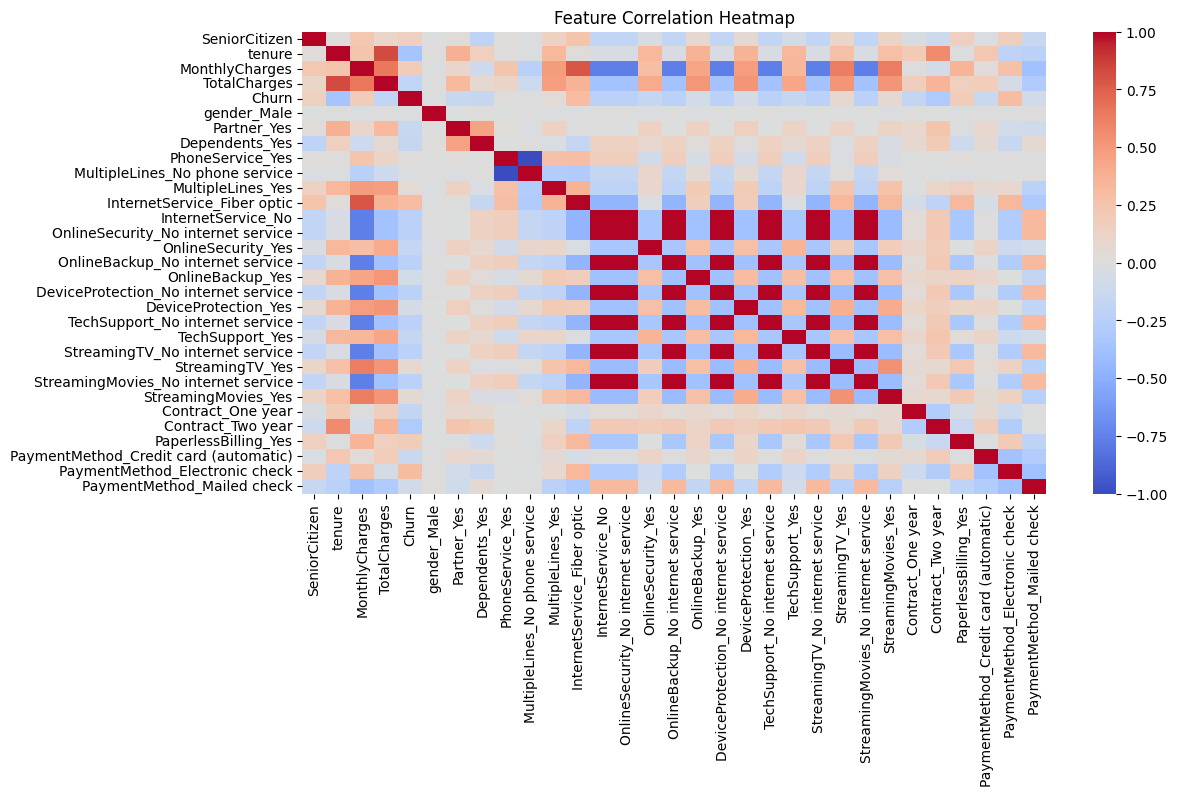

In [67]:

plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [75]:
import os
os.makedirs("models", exist_ok=True)
import joblib
joblib.dump(model, "models/churn_model.pkl")

['models/churn_model.pkl']

In [76]:
import joblib

joblib.dump(X.columns, "models/columns.pkl")

['models/columns.pkl']